In [12]:
import pandas as pd

# Load dataset
df = pd.read_csv('DataSets/AB_NYC_2019.csv')

# Drop missing values and remove listings with price <= 0
df = df.dropna()
df = df[df['price'] > 0]
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48782,36425863,Lovely Privet Bedroom with Privet Restroom,83554966,Rusaa,Manhattan,Upper East Side,40.78099,-73.95366,Private room,129,1,1,2019-07-07,1.00,1,147
48790,36427429,No.2 with queen size bed,257683179,H Ai,Queens,Flushing,40.75104,-73.81459,Private room,45,1,1,2019-07-07,1.00,6,339
48799,36438336,Seas The Moment,211644523,Ben,Staten Island,Great Kills,40.54179,-74.14275,Private room,235,1,1,2019-07-07,1.00,1,87
48805,36442252,1B-1B apartment near by Metro,273841667,Blaine,Bronx,Mott Haven,40.80787,-73.92400,Entire home/apt,100,1,2,2019-07-07,2.00,1,40


In [13]:
# Calculate mean and standard deviation of price
mean_price = df['price'].mean()
std_price = df['price'].std()

print("Mean price:", mean_price)
print("Standard deviation:", std_price)


Mean price: 142.36919945376312
Standard deviation: 197.00688260669816


In [14]:
# Compute Z-score for each listing
df['zscore'] = (df['price'] - mean_price) / std_price

# Preview Z-scores
print(df[['price', 'zscore']].head())


   price    zscore
0    149  0.033658
1    225  0.419431
3     89 -0.270900
4     80 -0.316584
5    200  0.292532


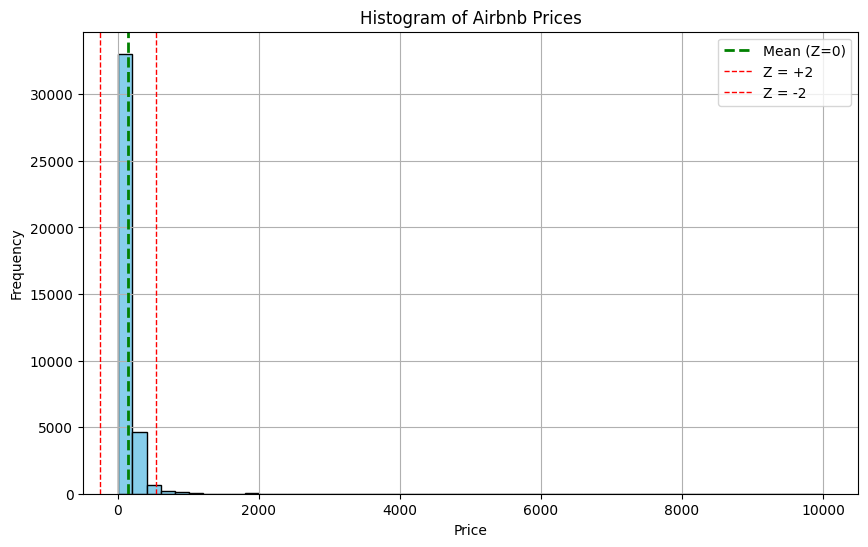

In [15]:
import matplotlib.pyplot as plt

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')

# Overlay Z-score thresholds
plt.axvline(mean_price, color='green', linestyle='dashed', linewidth=2, label='Mean (Z=0)')
plt.axvline(mean_price + 2*std_price, color='red', linestyle='dashed', linewidth=1, label='Z = +2')
plt.axvline(mean_price - 2*std_price, color='red', linestyle='dashed', linewidth=1, label='Z = -2')

plt.title('Histogram of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
#Filter out outliers using Z-score
filtered_df = df[(df['zscore'] > -2) & (df['zscore'] < 2)]
filtered_df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,zscore
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,0.033658
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,0.419431
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,-0.270900
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,-0.316584
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,0.292532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48782,36425863,Lovely Privet Bedroom with Privet Restroom,83554966,Rusaa,Manhattan,Upper East Side,40.78099,-73.95366,Private room,129,1,1,2019-07-07,1.00,1,147,-0.067862
48790,36427429,No.2 with queen size bed,257683179,H Ai,Queens,Flushing,40.75104,-73.81459,Private room,45,1,1,2019-07-07,1.00,6,339,-0.494243
48799,36438336,Seas The Moment,211644523,Ben,Staten Island,Great Kills,40.54179,-74.14275,Private room,235,1,1,2019-07-07,1.00,1,87,0.470191
48805,36442252,1B-1B apartment near by Metro,273841667,Blaine,Bronx,Mott Haven,40.80787,-73.92400,Entire home/apt,100,1,2,2019-07-07,2.00,1,40,-0.215065


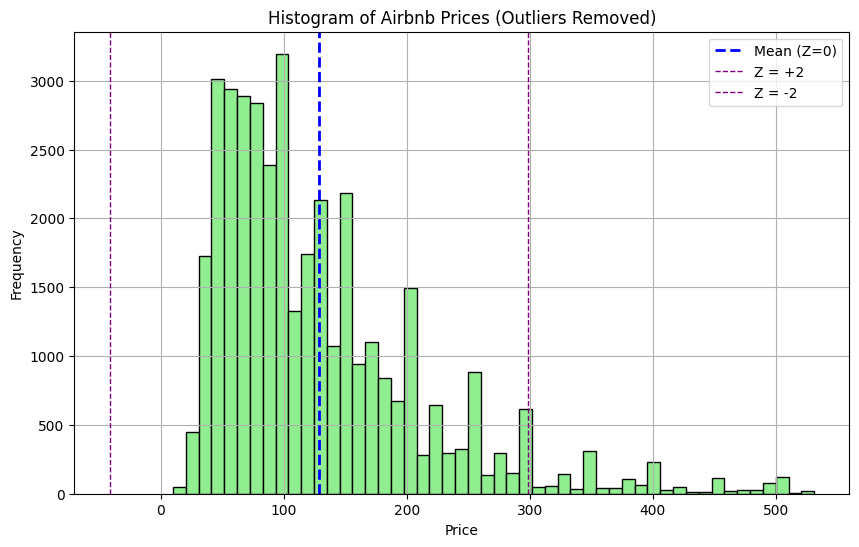

In [17]:
# Plot cleaned histogram
mean_filtered = filtered_df['price'].mean()
std_filtered = filtered_df['price'].std()

plt.figure(figsize=(10, 6))
plt.hist(filtered_df['price'], bins=50, color='lightgreen', edgecolor='black')
plt.axvline(mean_filtered, color='blue', linestyle='dashed', linewidth=2, label='Mean (Z=0)')
plt.axvline(mean_filtered + 2*std_filtered, color='purple', linestyle='dashed', linewidth=1, label='Z = +2')
plt.axvline(mean_filtered - 2*std_filtered, color='purple', linestyle='dashed', linewidth=1, label='Z = -2')
plt.title('Histogram of Airbnb Prices (Outliers Removed)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()